In [16]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [ ]:
def magic_mask(w, h, t, b, l, r):
    ttb, _ = np.mgrid[0:h:1, 0:w//2:1]
    res[:, :w//2] = ttb[:, :w//2] * l
    res[:, w//2:] = ttb[:, w//2:] * r
    return res

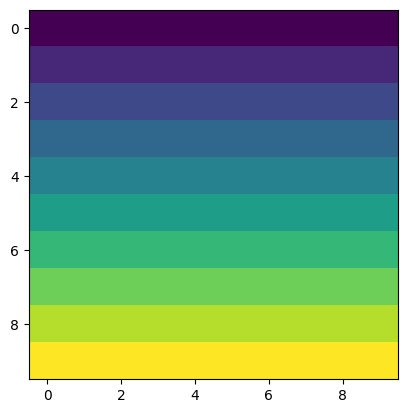

In [18]:
mask = magic_mask(20, 10, 0, 1, 1, -1)
plt.imshow(mask)

In [19]:
mask = mask_generation(300, 200, 350)
plt.imshow(mask)

NameError: name 'mask_generation' is not defined

In [ ]:

def centre_of_mass_lr(mask, l, r):
    h = mask.shape[1] // 2
    Y_l, X_l = np.mgrid[0:mask.shape[0]:1, 0:h:1]
    Y_r, X_r = np.mgrid[0:mask.shape[0]:1, h:mask.shape[1]:1]

    if np.count_nonzero(mask):
        mask_l = mask[:, :h]
        mask_r = mask[:, h:]

        centroid_x_l = int(float(np.sum(cv2.bitwise_and(X_l, X_l, mask=mask_l)))) * l
        centroid_y_l = int(float(np.sum(cv2.bitwise_and(Y_l, Y_l, mask=mask_l)))) * l
        centroid_x_r = int(float(np.sum(cv2.bitwise_and(X_r, X_r, mask=mask_r)))) * r
        centroid_y_r = int(float(np.sum(cv2.bitwise_and(Y_r, Y_r, mask=mask_r)))) * r
        centroid_x = (centroid_x_l + centroid_x_r)/(np.count_nonzero(mask_r) * r + np.count_nonzero(mask_l) * l)
        centroid_y = (centroid_y_l + centroid_y_r)/(np.count_nonzero(mask_r) * r + np.count_nonzero(mask_l) * l)
    else:
        centroid_x = mask.shape[1] / 2
        centroid_y = mask.shape[0] / 2

    return(centroid_x, centroid_y)


In [ ]:
centre_of_mass_lr(mask, 2, 1)

(130.7252123762762, 86.14313771335048)

In [ ]:
v = np.array([[0, 0, 0, 0], [0, 1, 0, 0]])
np.argmax(np.any(v, axis=1))

np.int64(1)

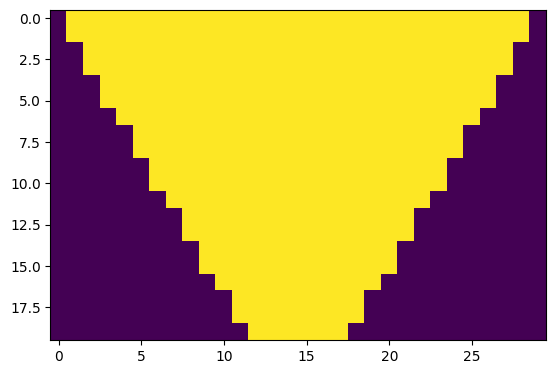

In [ ]:
plt.imshow(mask_generation(30, 20, 25))

In [ ]:
print(np.argmax(mask_generation(30, 20, 25)[::-1, :], axis=0))

[ 0 18 16 14 13 11  9  8  6  4  3  1  0  0  0  0  0  0  1  3  4  6  8  9
 11 13 14 16 18  0]
